In [47]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

ROOT = Path("../").resolve()
RESULTS_DIR = ROOT / "evaluation"
LEAD_TIMES = [1, 2, 3, 4, 5, 6, 7, 10, 14, 21, 28]

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1. Load results

In [48]:
def load_all(results_dir: Path) -> pd.DataFrame:
    dfs = []
    for f in sorted(results_dir.glob("*/eval_*.csv")):
        parts = f.stem.split("_")  # ['eval', model, 'n{n_in}']
        if len(parts) < 3:
            print(f"Skipping {f.name} — unexpected filename format")
            continue
        model = "_".join(parts[1:-1])  # handles names like conv_lstm
        n_in = int(parts[-1][1:])      # strip leading 'n'
        df = pd.read_csv(f)
        df["model"] = model
        df["n_in"]  = n_in
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)


df = load_all(RESULTS_DIR)

# add skill score relative to persistence
pers = (
    df[df["method"] == "persistence"][["lead_days", "n_in", "rmse"]]
    .rename(columns={"rmse": "rmse_pers"})
)
df = df.merge(pers, on=["lead_days", "n_in"])
df["skill"] = 1 - df["rmse"] / df["rmse_pers"]
df["score"] = 0.5 * df["skill"] + 0.5 * df["acc"]

# separate baselines from learned models
BASELINES = ["persistence"]
df_models = df[~df["method"].isin(BASELINES)].copy()
df_models = df
print(f"Loaded {len(df)} rows — models: {df['model'].unique()}, n_in: {sorted(df['n_in'].unique())}")
df.head()

Loaded 198 rows — models: ['conv_lstm' 'lstm'], n_in: [np.int64(14), np.int64(21), np.int64(28)]


,method,lead_days,rmse,acc,model,n_in,rmse_pers,skill,score
0,model,1,0.120911,0.985026,conv_lstm,14,0.131170,0.078211,0.531619
1,model,1,0.120911,0.985026,conv_lstm,14,0.131083,0.077600,0.531313
2,model,2,0.196107,0.960446,conv_lstm,14,0.209662,0.064652,0.512549
3,model,2,0.196107,0.960446,conv_lstm,14,0.209662,0.064652,0.512549
4,model,3,0.249573,0.936249,conv_lstm,14,0.263710,0.053608,0.494929


## 2. Summary table — best config per lead time

In [49]:
summary = (
    df_models
    .groupby(["model", "n_in", "lead_days"])[["rmse", "acc", "skill", "score"]]
    .mean()
    .reset_index()
)

best_per_lead = (
    summary
    .sort_values("score", ascending=False)
    .groupby("lead_days")
    .first()
    .reset_index()[["lead_days", "model", "n_in", "rmse", "acc", "skill", "score"]]
)
print("Best config per lead time:")
best_per_lead.style.format({"rmse": "{:.4f}", "acc": "{:.4f}", "skill": "{:.4f}", "score": "{:.4f}"})

Best config per lead time:


,lead_days,model,n_in,rmse,acc,skill,score
0,1,conv_lstm,14,0.1269,0.9835,0.0320,0.5078
1,2,conv_lstm,14,0.2069,0.9565,0.0130,0.4848
2,3,conv_lstm,14,0.2619,0.9306,0.0068,0.4687
3,4,conv_lstm,14,0.3033,0.9071,0.0061,0.4566
4,5,conv_lstm,14,0.3370,0.8855,0.0063,0.4459
5,6,conv_lstm,14,0.3654,0.8655,0.0074,0.4365
6,7,conv_lstm,14,0.3898,0.8469,0.0082,0.4276
7,10,lstm,21,0.4458,0.7955,0.0140,0.4048
8,14,lstm,14,0.5011,0.7386,0.0210,0.3798
9,21,lstm,21,0.5624,0.6637,0.0354,0.3495


## 3. Fig 1 — RMSE & ACC vs lead time (faceted by n_in)

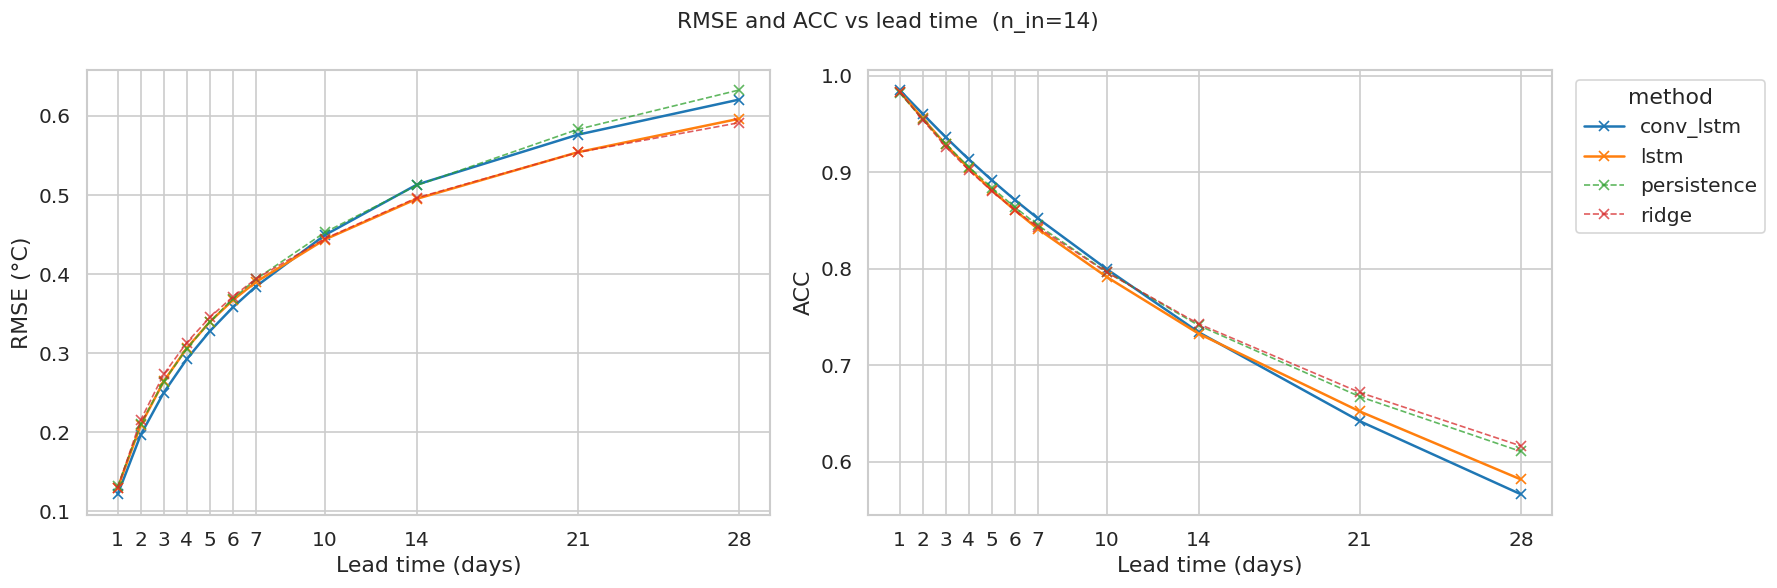

In [50]:
n_ins = sorted(df["n_in"].unique())

# For learned models, label by architecture name; for baselines, label by method name
df["label"] = df.apply(
    lambda r: r["model"] if r["method"] == "model" else r["method"], axis=1
)

BASELINE_METHODS = ["persistence", "ridge"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

n_in = 14  # we onlu have 14 with conv lsstm for now
sub = df[df["n_in"] == n_in].groupby(["label", "lead_days"])[["rmse", "acc"]].mean().reset_index()

for label, grp in sub.groupby("label"):
    grp = grp.sort_values("lead_days")
    is_baseline = label in BASELINE_METHODS
    style = dict(
        marker="x",
        linestyle="--" if is_baseline else "-",
        linewidth=1  if is_baseline else 1.5,
        alpha=0.75     if is_baseline else 1.0,
    )
    axes[0].plot(grp["lead_days"], grp["rmse"], label=label, **style)
    axes[1].plot(grp["lead_days"], grp["acc"],  label=label, **style)

for ax, metric in zip(axes, ["RMSE (°C)", "ACC"]):
    ax.set_xlabel("Lead time (days)")
    ax.set_ylabel(metric)
    ax.set_xticks(LEAD_TIMES)

axes[1].legend(title="method", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle(f"RMSE and ACC vs lead time  (n_in={n_in})", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig1_rmse_acc_vs_lead.png", bbox_inches="tight")
plt.show()

## 4. Fig 2 — Skill score heatmap (config × lead time)

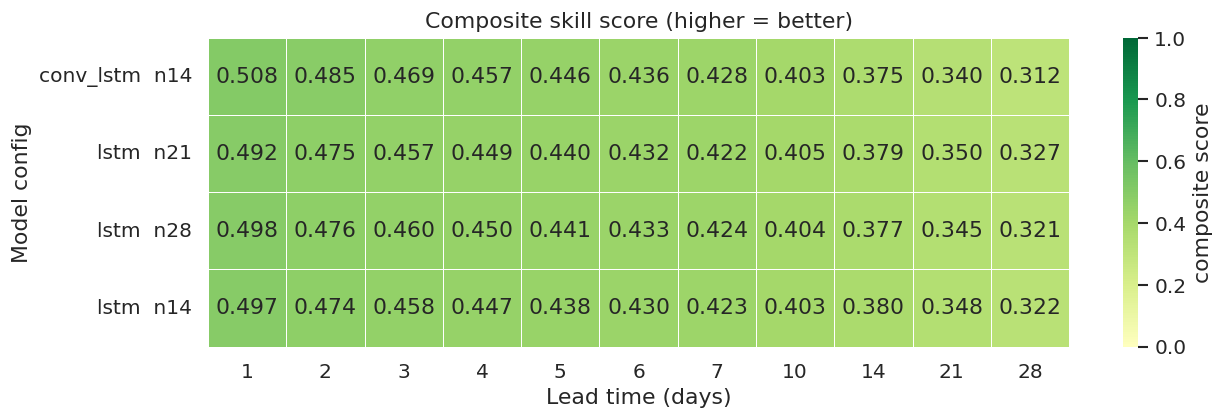

In [58]:
pivot = (
    df_models
    .assign(config=lambda d: d["model"] + "  n" + d["n_in"].astype(str))
    .pivot_table(index="config", columns="lead_days", values="score", aggfunc="mean")
)
# sort rows by mean score descending
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(len(LEAD_TIMES), 0.55 * len(pivot) + 1.5))
sns.heatmap(
    pivot, annot=True, fmt=".3f",
    cmap="RdYlGn", center=0, vmin=0, vmax=1.0,
    linewidths=0.5, ax=ax, cbar_kws={"label": "composite score"}
)
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("Model config")
ax.set_title("Composite skill score (higher = better)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig2_skill_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Fig 3 — Overall ranking (average score across all lead times)

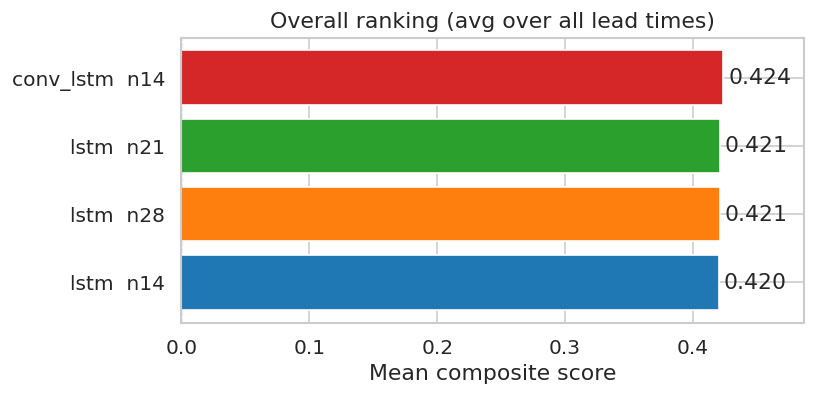


Best overall: conv_lstm  n14  (score=0.4235)


In [56]:
overall = (
    df_models
    .groupby(["model", "n_in"])["score"]
    .mean()
    .reset_index()
    .sort_values("score")
)
overall["config"] = overall["model"] + "  n" + overall["n_in"].astype(str)

fig, ax = plt.subplots(figsize=(7, 0.5 * len(overall) + 1.5))
bars = ax.barh(
    overall["config"], overall["score"],
    color=sns.color_palette("tab10", len(overall))
)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_xlabel("Mean composite score")
ax.set_title("Overall ranking (avg over all lead times)")
ax.set_xlim(right=overall["score"].max() * 1.15)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig3_overall_ranking.png", bbox_inches="tight")
plt.show()

best = overall.iloc[-1]
print(f"\nBest overall: {best['config']}  (score={best['score']:.4f})")

## 6. Baselines comparison

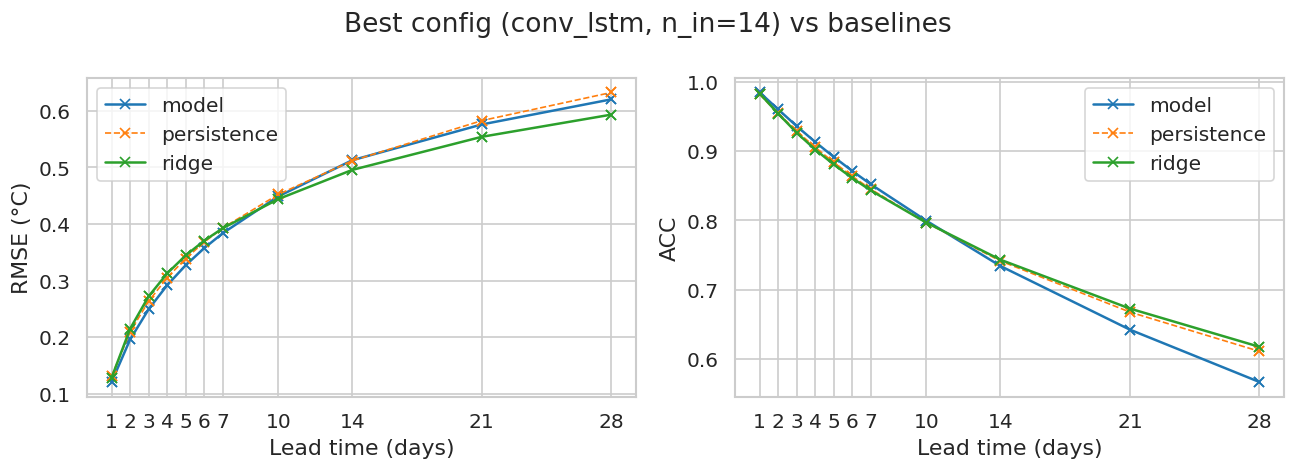

In [57]:
# Compare best model config against baselines at each lead time
best_model_cfg = overall.iloc[-1][["model", "n_in"]]
best_df = df[
    (df["model"] == best_model_cfg["model"]) &
    (df["n_in"]  == best_model_cfg["n_in"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method, grp in best_df.groupby("method"):
    grp = grp.sort_values("lead_days")
    style = dict(marker="x", linestyle="--" if method in BASELINES else "-",
                 linewidth=1 if method in BASELINES else 1.5)
    axes[0].plot(grp["lead_days"], grp["rmse"], label=method, **style)
    axes[1].plot(grp["lead_days"], grp["acc"],  label=method, **style)

for ax, metric in zip(axes, ["RMSE (°C)", "ACC"]):
    ax.set_xlabel("Lead time (days)")
    ax.set_ylabel(metric)
    ax.set_xticks(LEAD_TIMES)
    ax.legend()

fig.suptitle(f"Best config ({best_model_cfg['model']}, n_in={best_model_cfg['n_in']}) vs baselines")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "fig5_best_vs_baselines.png", bbox_inches="tight")
plt.show()